In [11]:
!pip install yfinance --quiet

In [12]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

test = yf.Ticker("TCS.NS")
print(test.info.get("longName"), test.info.get("trailingPE"))

Tata Consultancy Services Limited 16.339914


In [13]:
tickers = ["HINDUNILVR.NS", "ITC.NS", "NESTLEIND.NS", "MARICO.NS", "COLPAL.NS", "EMAMILTD.NS"]

data = []

for t in tickers:
    info = yf.Ticker(t).info
    data.append({
        "ticker": t,
        "name": info.get("shortName"),
        "pe": info.get("trailingPE"),
        "pb": info.get("priceToBook"),
        "ev_ebitda": info.get("enterpriseToEbitda"),
        "market_cap": info.get("marketCap")
    })

df = pd.DataFrame(data)
df

,ticker,name,pe,pb,ev_ebitda,market_cap
0,HINDUNILVR.NS,HINDUSTAN UNILEVER LTD.,44.645794,9.691664,31.460,4723618349056
1,ITC.NS,ITC LTD,16.975111,4.596589,12.374,3332921884672
2,NESTLEIND.NS,NESTLE INDIA LIMITED,73.538925,54.391804,49.895,2804926119936
3,MARICO.NS,MARICO LIMITED,56.864292,25.582006,43.926,1075372883968
4,COLPAL.NS,COLGATE PALMOLIVE LTD.,36.810400,31.367397,25.958,496890544128
5,EMAMILTD.NS,EMAMI LIMITED,22.135357,5.663786,16.420,165608095744


In [14]:
avg_pe = df["pe"].mean()
avg_pb = df["pb"].mean()
avg_ev_ebitda = df["ev_ebitda"].mean()

df["pe_vs_peer"] = df["pe"] - avg_pe
df["ev_ebitda_vs_peer"] = df["ev_ebitda"] - avg_ev_ebitda

df_sorted = df.sort_values("pe", ascending=False)
df_sorted

,ticker,name,pe,pb,ev_ebitda,market_cap,pe_vs_peer,ev_ebitda_vs_peer
2,NESTLEIND.NS,NESTLE INDIA LIMITED,73.538925,54.391804,49.895,2804926119936,31.710612,19.8895
3,MARICO.NS,MARICO LIMITED,56.864292,25.582006,43.926,1075372883968,15.035979,13.9205
0,HINDUNILVR.NS,HINDUSTAN UNILEVER LTD.,44.645794,9.691664,31.460,4723618349056,2.817481,1.4545
4,COLPAL.NS,COLGATE PALMOLIVE LTD.,36.810400,31.367397,25.958,496890544128,-5.017913,-4.0475
5,EMAMILTD.NS,EMAMI LIMITED,22.135357,5.663786,16.420,165608095744,-19.692956,-13.5855
1,ITC.NS,ITC LTD,16.975111,4.596589,12.374,3332921884672,-24.853202,-17.6315


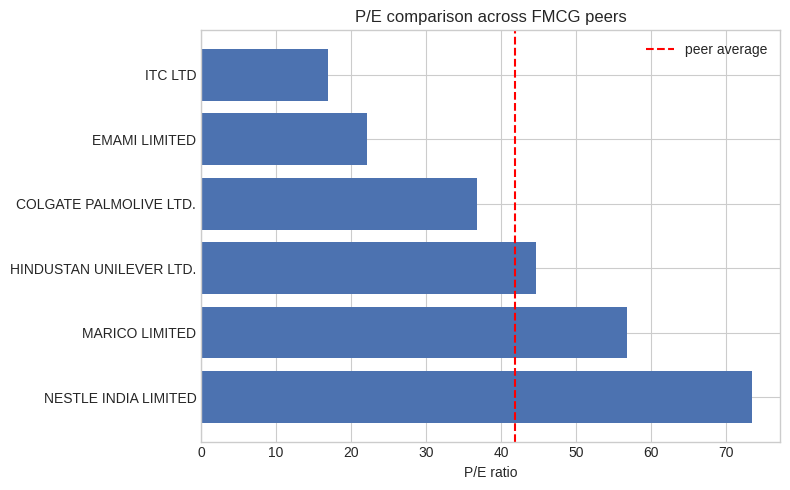

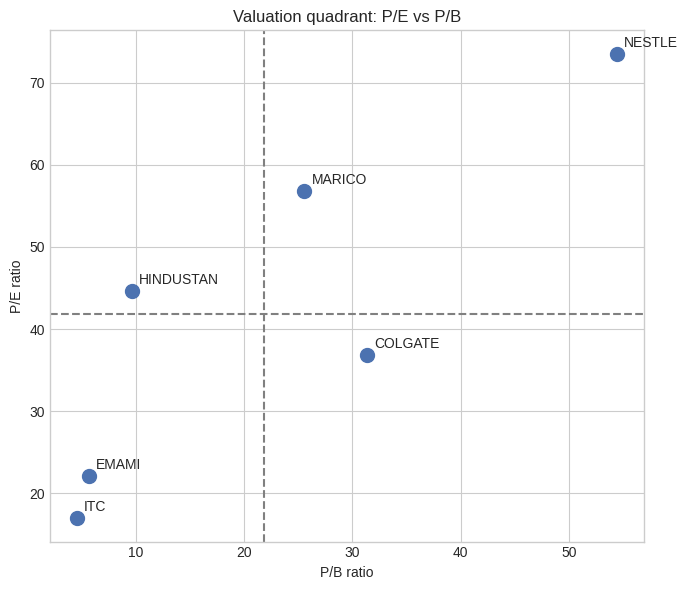

In [15]:
plt.style.use("seaborn-v0_8-whitegrid")

# horizontal bar chart
plt.figure(figsize=(8,5))
plt.barh(df_sorted["name"], df_sorted["pe"], color="#4C72B0")
plt.axvline(avg_pe, color="red", linestyle="--", label="peer average")
plt.xlabel("P/E ratio")
plt.title("P/E comparison across FMCG peers")
plt.legend()
plt.tight_layout()
plt.savefig("pe_horizontal.png")
plt.show()

# valuation quadrant scatter
plt.figure(figsize=(7,6))
plt.scatter(df["pb"], df["pe"], s=100, color="#4C72B0")

for i, row in df.iterrows():
    plt.annotate(row["name"].split()[0], (row["pb"], row["pe"]), xytext=(5,5), textcoords="offset points")

plt.axvline(avg_pb, color="grey", linestyle="--")
plt.axhline(avg_pe, color="grey", linestyle="--")
plt.xlabel("P/B ratio")
plt.ylabel("P/E ratio")
plt.title("Valuation quadrant: P/E vs P/B")
plt.tight_layout()
plt.savefig("valuation_quadrant.png")
plt.show()

Key Findings:
1. When comparing P/E ratios across 6 FMCG companies, it turned out varying from 17x for ITC to 73.5x for Nestle India. This wide range of the ratios mainly resulted from the diversified businesses and brand strength of these companies.
2. But, the share price of Nestle and Marico seems A lot higher based on P/E and P/B ratios than the industry average. Such a scenario indicates that the investors not only anticipate more growth from the company but also are ready to pay a premium for the quality products of the company's strong brands.
3. ITC is the only company that has both of its ratios lower than the industry average. From its varied line of businesses, including its tobacco business that typically does not fetch high valuations.